In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [10]:
df = pd.read_csv("C:/Users/yulor/Downloads/merged_flight_weather 2.csv")

df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')
df['month_label'] = df['date'].dt.strftime('%b %Y')

daily = df.groupby(['date', 'origin', 'destination']).agg(
    cancellations  = ('airline',            'count'),
    origin_tavg    = ('origin_tavg',        'first'),
    origin_prcp    = ('origin_prcp',        'first'),
    origin_snow    = ('origin_snow',        'first'),
    origin_wspd    = ('origin_wspd',        'first'),
    dest_prcp      = ('destination_prcp',   'first'),
    dest_snow      = ('destination_snow',   'first'),
    dest_wspd      = ('destination_wspd',   'first'),
).reset_index()

# Airline tier classification
budget_airlines = ['F9', 'NK']   # Frontier, Spirit
premium_airlines = ['AA', 'AS']  # American, Alaska
df['airline_tier'] = df['airline'].apply(lambda x: 'Budget' if x in budget_airlines else 'Premium')

# Ordered months for consistent axis labels
month_order = ['Dec 2024', 'Jan 2025', 'Feb 2025']

# Color palette
COLORS = {
    'AA': '#ff6b35',
    'NK': '#c77dff',
    'F9': '#ffe66d',
    'AS': '#4ecdc4',
    'Budget':  '#ffe66d',
    'Premium': '#ff6b35',
    'LGA': '#4ecdc4',
    'ORD': '#ff6b35',
    'DFW': '#ffe66d',
    'BOS': '#c77dff',
    'SFO': '#a8dadc',
    'EWR': '#ff9a6c',
}

BG      = '#0b0c10'
SURFACE = '#13151c'
MUTED   = '#6b7280'
TEXT    = '#e8eaf0'
GRID    = '#1f2230'
C1      = '#ff6b35'   # orange
C2      = '#4ecdc4'   # teal
C3      = '#ffe66d'   # yellow
C4      = '#c77dff'   # purple

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    SURFACE,
    'axes.edgecolor':    GRID,
    'axes.labelcolor':   MUTED,
    'xtick.color':       MUTED,
    'ytick.color':       MUTED,
    'grid.color':        GRID,
    'text.color':        TEXT,
    'font.family':       'monospace',
    'axes.grid':         True,
    'grid.linewidth':    0.6,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

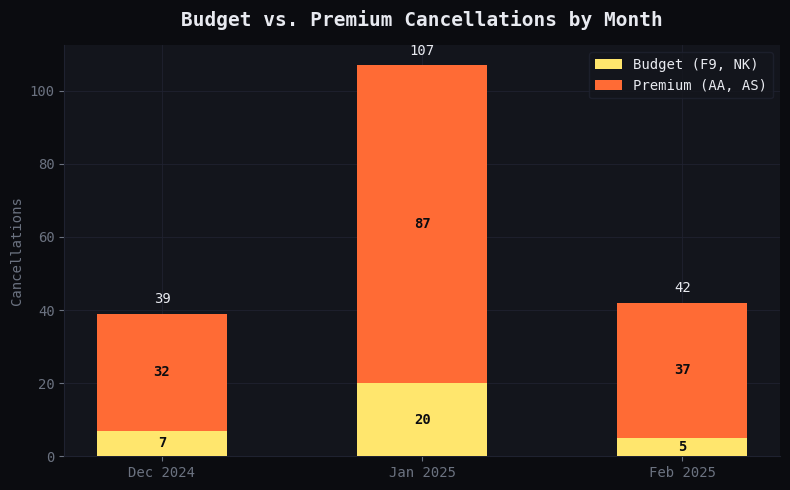

In [5]:
tier_month = (
    df.groupby(['month_label', 'airline_tier'])
    .size()
    .reset_index(name='cancellations')
)
# Pivot so Budget and Premium are columns
pivot = tier_month.pivot(index='month_label', columns='airline_tier', values='cancellations').fillna(0)
pivot = pivot.reindex(month_order)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)

bars_budget  = ax.bar(pivot.index, pivot['Budget'],  color=COLORS['Budget'],  label='Budget (F9, NK)', width=0.5, zorder=3)
bars_premium = ax.bar(pivot.index, pivot['Premium'], color=COLORS['Premium'], label='Premium (AA, AS)', width=0.5,
                      bottom=pivot['Budget'], zorder=3)

# Value labels on stacked bars
for i, (b, p) in enumerate(zip(pivot['Budget'], pivot['Premium'])):
    ax.text(i, b / 2,          f'{int(b)}', ha='center', va='center', fontsize=10, fontweight='bold', color=BG)
    ax.text(i, b + p / 2,      f'{int(p)}', ha='center', va='center', fontsize=10, fontweight='bold', color=BG)
    ax.text(i, b + p + 2,      f'{int(b+p)}', ha='center', va='bottom', fontsize=10, color=TEXT)

ax.set_title('Budget vs. Premium Cancellations by Month', fontsize=14, fontweight='bold', color=TEXT, pad=14)
ax.set_ylabel('Cancellations', color=MUTED)
ax.legend(facecolor=SURFACE, edgecolor=GRID, labelcolor=TEXT)
plt.tight_layout()
plt.show()

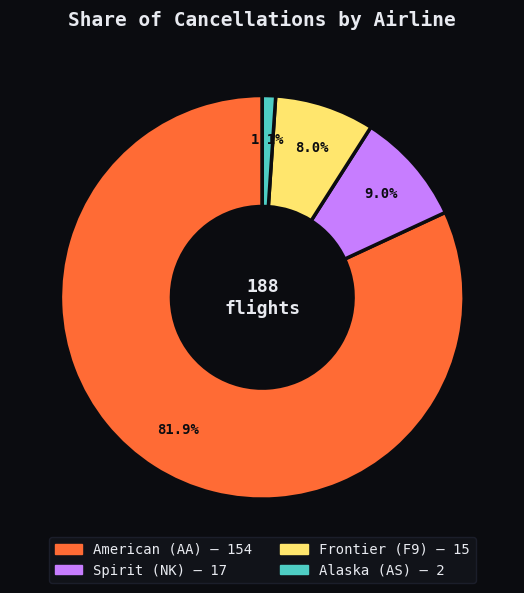

In [6]:
by_airline = df['airline'].value_counts().reset_index()
by_airline.columns = ['airline', 'cancellations']
airline_names = {'AA': 'American (AA)', 'NK': 'Spirit (NK)', 'F9': 'Frontier (F9)', 'AS': 'Alaska (AS)'}

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

wedge_colors = [COLORS[a] for a in by_airline['airline']]
wedges, texts, autotexts = ax.pie(
    by_airline['cancellations'],
    labels=None,
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2.5),
    pctdistance=0.78,
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_color(BG)
    at.set_fontweight('bold')

# Center annotation
ax.text(0, 0, '188\nflights', ha='center', va='center', fontsize=13, fontweight='bold', color=TEXT)

legend_patches = [
    mpatches.Patch(color=COLORS[row['airline']], label=f"{airline_names[row['airline']]} — {row['cancellations']}")
    for _, row in by_airline.iterrows()
]
ax.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.08),
          ncol=2, facecolor=SURFACE, edgecolor=GRID, labelcolor=TEXT, fontsize=10)
ax.set_title('Share of Cancellations by Airline', fontsize=14, fontweight='bold', color=TEXT, pad=14)
plt.tight_layout()
plt.show()

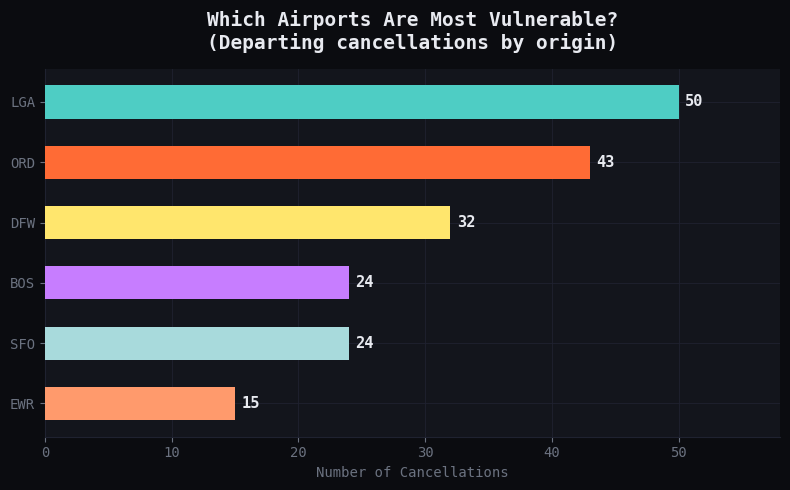

In [7]:
by_origin = df['origin'].value_counts().reset_index()
by_origin.columns = ['origin', 'cancellations']
by_origin = by_origin.sort_values('cancellations')   # ascending so largest is on top

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)

bar_colors = [COLORS.get(o, '#aaaaaa') for o in by_origin['origin']]
bars = ax.barh(by_origin['origin'], by_origin['cancellations'], color=bar_colors, height=0.55, zorder=3)

for bar, val in zip(bars, by_origin['cancellations']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left', fontsize=11, color=TEXT, fontweight='bold')

ax.set_xlabel('Number of Cancellations', color=MUTED)
ax.set_title('Which Airports Are Most Vulnerable?\n(Departing cancellations by origin)', fontsize=14, fontweight='bold', color=TEXT, pad=14)
ax.set_xlim(0, by_origin['cancellations'].max() + 8)
plt.tight_layout()
plt.show()

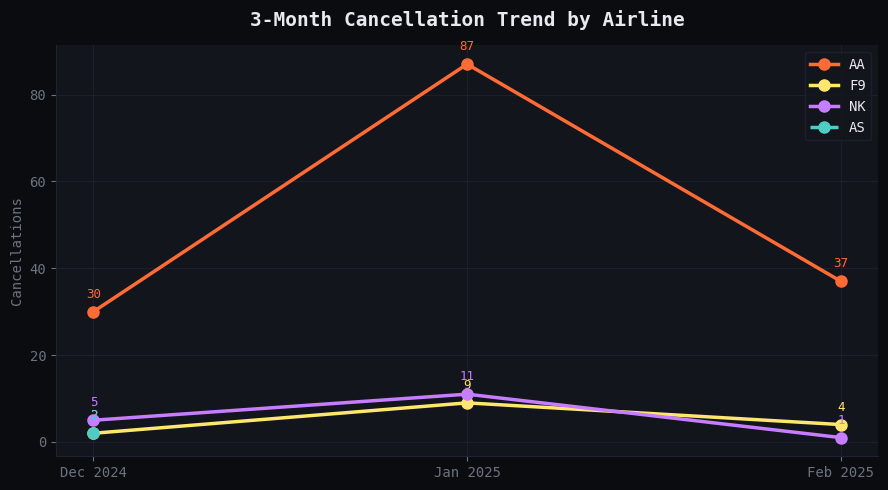

In [8]:
monthly = (
    df.groupby(['month_label', 'airline'])
    .size()
    .reset_index(name='cancellations')
)
monthly['month_label'] = pd.Categorical(monthly['month_label'], categories=month_order, ordered=True)
monthly = monthly.sort_values('month_label')

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)

for airline in ['AA', 'F9', 'NK', 'AS']:
    subset = monthly[monthly['airline'] == airline]
    style  = '--' if airline == 'AS' else '-'
    ax.plot(subset['month_label'], subset['cancellations'],
            marker='o', markersize=8, linewidth=2.5,
            color=COLORS[airline], label=airline, linestyle=style, zorder=3)
    for _, row in subset.iterrows():
        ax.annotate(f"{int(row['cancellations'])}",
                    (row['month_label'], row['cancellations']),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9, color=COLORS[airline])

ax.set_title('3-Month Cancellation Trend by Airline', fontsize=14, fontweight='bold', color=TEXT, pad=14)
ax.set_ylabel('Cancellations', color=MUTED)
ax.legend(facecolor=SURFACE, edgecolor=GRID, labelcolor=TEXT)
plt.tight_layout()
plt.show()

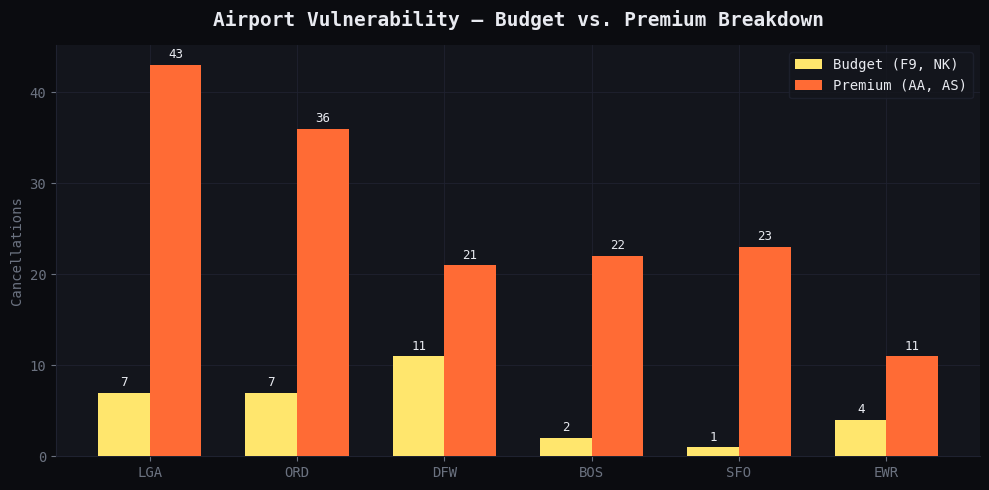

In [9]:
vuln = (
    df.groupby(['origin', 'airline_tier'])
    .size()
    .reset_index(name='cancellations')
)
vuln_pivot = vuln.pivot(index='origin', columns='airline_tier', values='cancellations').fillna(0)
# Sort by total
vuln_pivot['total'] = vuln_pivot.sum(axis=1)
vuln_pivot = vuln_pivot.sort_values('total', ascending=False).drop(columns='total')

airports = vuln_pivot.index.tolist()
x = np.arange(len(airports))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)

b1 = ax.bar(x - w/2, vuln_pivot['Budget'],  width=w, color=COLORS['Budget'],  label='Budget (F9, NK)',  zorder=3)
b2 = ax.bar(x + w/2, vuln_pivot['Premium'], width=w, color=COLORS['Premium'], label='Premium (AA, AS)', zorder=3)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                str(int(h)), ha='center', va='bottom', fontsize=9, color=TEXT)

ax.set_xticks(x)
ax.set_xticklabels(airports)
ax.set_ylabel('Cancellations', color=MUTED)
ax.set_title('Airport Vulnerability — Budget vs. Premium Breakdown', fontsize=14, fontweight='bold', color=TEXT, pad=14)
ax.legend(facecolor=SURFACE, edgecolor=GRID, labelcolor=TEXT)
plt.tight_layout()
plt.show()


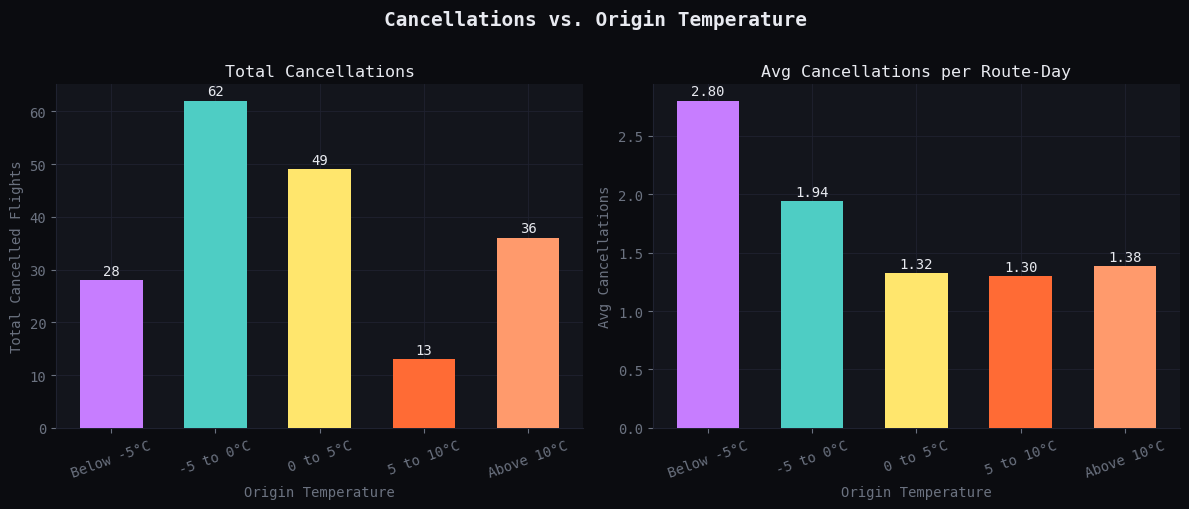

In [11]:
daily['temp_bin'] = pd.cut(
    daily['origin_tavg'],
    bins=[-25, -5, 0, 5, 10, 25],
    labels=['Below -5°C', '-5 to 0°C', '0 to 5°C', '5 to 10°C', 'Above 10°C']
)
temp_stats = daily.groupby('temp_bin', observed=True)['cancellations'].agg(['sum', 'mean']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Cancellations vs. Origin Temperature', fontsize=14, fontweight='bold', color=TEXT, y=1.01)

# Left: total cancellations
ax = axes[0]
bars = ax.bar(temp_stats['temp_bin'], temp_stats['sum'],
              color=[C4, C2, C3, C1, '#ff9a6c'], width=0.6, zorder=3)
for bar, val in zip(bars, temp_stats['sum']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(val)), ha='center', va='bottom', fontsize=10, color=TEXT)
ax.set_title('Total Cancellations', color=TEXT)
ax.set_xlabel('Origin Temperature', color=MUTED)
ax.set_ylabel('Total Cancelled Flights', color=MUTED)
ax.tick_params(axis='x', rotation=20)

# Right: avg cancellations per weather event
ax = axes[1]
bars = ax.bar(temp_stats['temp_bin'], temp_stats['mean'],
              color=[C4, C2, C3, C1, '#ff9a6c'], width=0.6, zorder=3)
for bar, val in zip(bars, temp_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, color=TEXT)
ax.set_title('Avg Cancellations per Route-Day', color=TEXT)
ax.set_xlabel('Origin Temperature', color=MUTED)
ax.set_ylabel('Avg Cancellations', color=MUTED)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

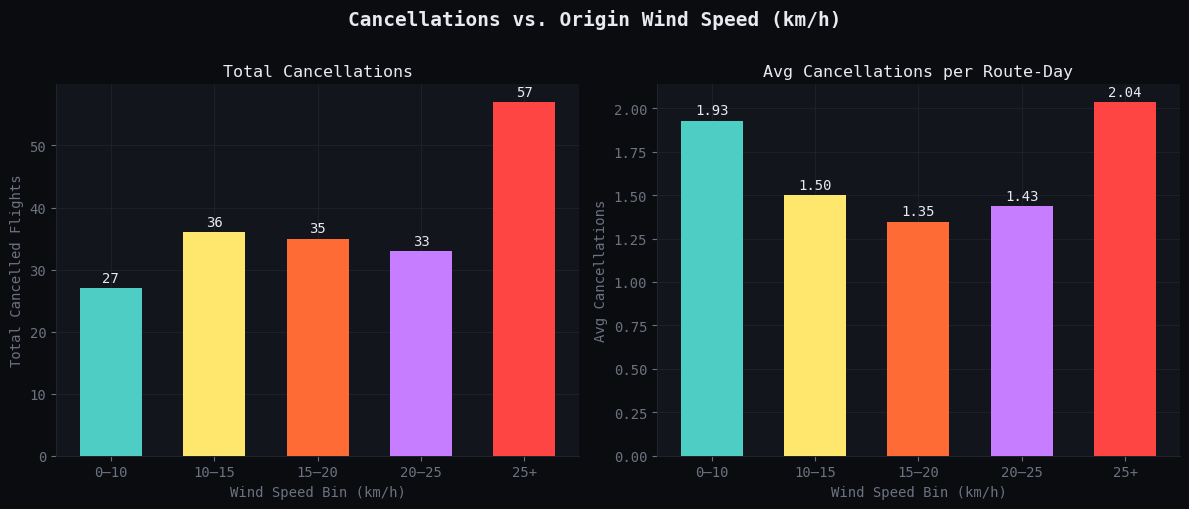

In [12]:
daily['wspd_bin'] = pd.cut(
    daily['origin_wspd'],
    bins=[0, 10, 15, 20, 25, 55],
    labels=['0–10', '10–15', '15–20', '20–25', '25+']
)
wind_stats = daily.groupby('wspd_bin', observed=True)['cancellations'].agg(['sum', 'mean', 'count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Cancellations vs. Origin Wind Speed (km/h)', fontsize=14, fontweight='bold', color=TEXT, y=1.01)

wind_colors = [C2, C3, C1, C4, '#ff4444']

ax = axes[0]
bars = ax.bar(wind_stats['wspd_bin'], wind_stats['sum'], color=wind_colors, width=0.6, zorder=3)
for bar, val in zip(bars, wind_stats['sum']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(val)), ha='center', va='bottom', fontsize=10, color=TEXT)
ax.set_title('Total Cancellations', color=TEXT)
ax.set_xlabel('Wind Speed Bin (km/h)', color=MUTED)
ax.set_ylabel('Total Cancelled Flights', color=MUTED)

ax = axes[1]
bars = ax.bar(wind_stats['wspd_bin'], wind_stats['mean'], color=wind_colors, width=0.6, zorder=3)
for bar, val in zip(bars, wind_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, color=TEXT)
ax.set_title('Avg Cancellations per Route-Day', color=TEXT)
ax.set_xlabel('Wind Speed Bin (km/h)', color=MUTED)
ax.set_ylabel('Avg Cancellations', color=MUTED)

plt.tight_layout()
plt.show()

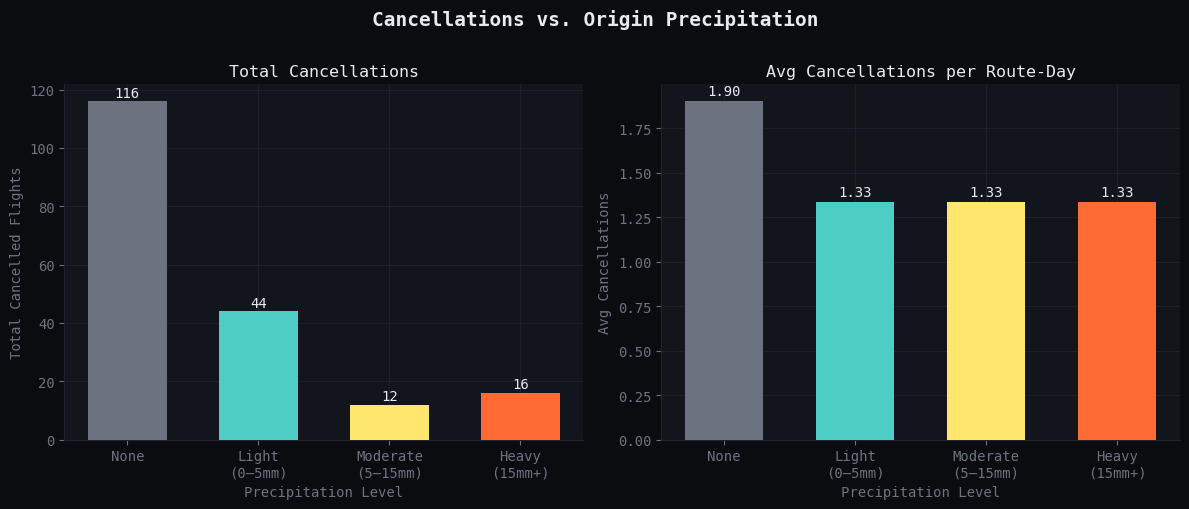

In [13]:
daily['prcp_bin'] = pd.cut(
    daily['origin_prcp'],
    bins=[-1, 0, 5, 15, 50],
    labels=['None', 'Light\n(0–5mm)', 'Moderate\n(5–15mm)', 'Heavy\n(15mm+)']
)
prcp_stats = daily.groupby('prcp_bin', observed=True)['cancellations'].agg(['sum', 'mean', 'count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Cancellations vs. Origin Precipitation', fontsize=14, fontweight='bold', color=TEXT, y=1.01)

prcp_colors = [MUTED, C2, C3, C1]

ax = axes[0]
bars = ax.bar(prcp_stats['prcp_bin'], prcp_stats['sum'], color=prcp_colors, width=0.6, zorder=3)
for bar, val in zip(bars, prcp_stats['sum']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(val)), ha='center', va='bottom', fontsize=10, color=TEXT)
ax.set_title('Total Cancellations', color=TEXT)
ax.set_xlabel('Precipitation Level', color=MUTED)
ax.set_ylabel('Total Cancelled Flights', color=MUTED)

ax = axes[1]
bars = ax.bar(prcp_stats['prcp_bin'], prcp_stats['mean'], color=prcp_colors, width=0.6, zorder=3)
for bar, val in zip(bars, prcp_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, color=TEXT)
ax.set_title('Avg Cancellations per Route-Day', color=TEXT)
ax.set_xlabel('Precipitation Level', color=MUTED)
ax.set_ylabel('Avg Cancellations', color=MUTED)

plt.tight_layout()
plt.show()

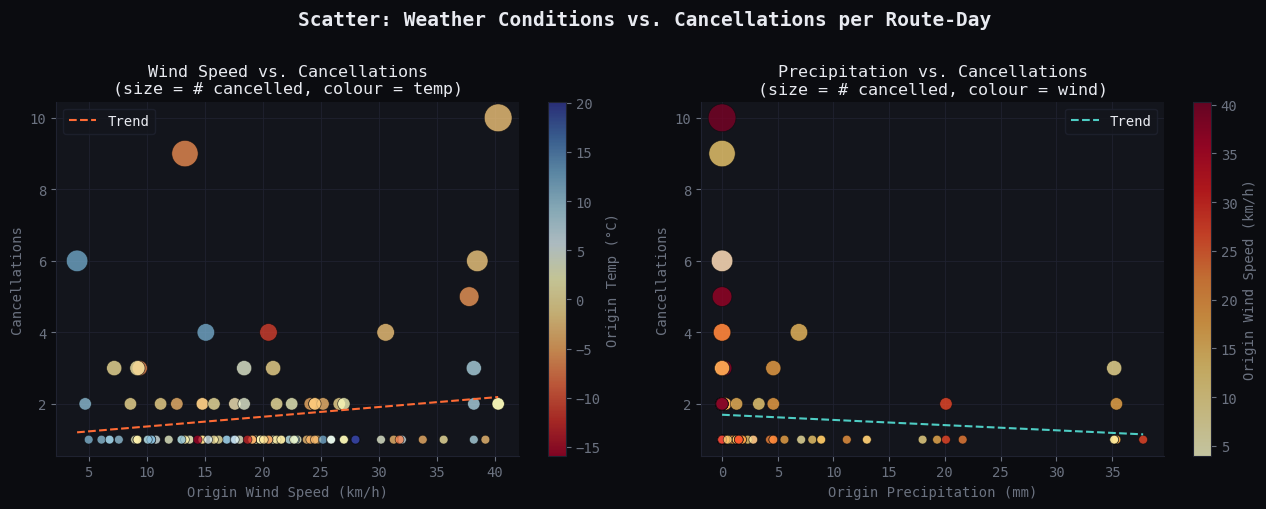

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Scatter: Weather Conditions vs. Cancellations per Route-Day',
             fontsize=14, fontweight='bold', color=TEXT, y=1.01)

# Left: wind speed vs cancellations, coloured by temperature
ax = axes[0]
sc = ax.scatter(daily['origin_wspd'], daily['cancellations'],
                c=daily['origin_tavg'], cmap='RdYlBu', alpha=0.75,
                s=daily['cancellations'] * 40, edgecolors=BG, linewidth=0.5, zorder=3)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Origin Temp (°C)', color=MUTED)
cbar.ax.yaxis.set_tick_params(color=MUTED)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=MUTED)

# Trend line
m, b = np.polyfit(daily['origin_wspd'], daily['cancellations'], 1)
x_line = np.linspace(daily['origin_wspd'].min(), daily['origin_wspd'].max(), 100)
ax.plot(x_line, m * x_line + b, color=C1, linewidth=1.5, linestyle='--', label='Trend', zorder=4)
ax.set_xlabel('Origin Wind Speed (km/h)', color=MUTED)
ax.set_ylabel('Cancellations', color=MUTED)
ax.set_title('Wind Speed vs. Cancellations\n(size = # cancelled, colour = temp)', color=TEXT)
ax.legend(facecolor=SURFACE, edgecolor=GRID, labelcolor=TEXT)

# Right: precipitation vs cancellations, coloured by wind speed
ax = axes[1]
sc2 = ax.scatter(daily['origin_prcp'], daily['cancellations'],
                 c=daily['origin_wspd'], cmap='YlOrRd', alpha=0.75,
                 s=daily['cancellations'] * 40, edgecolors=BG, linewidth=0.5, zorder=3)
cbar2 = fig.colorbar(sc2, ax=ax)
cbar2.set_label('Origin Wind Speed (km/h)', color=MUTED)
cbar2.ax.yaxis.set_tick_params(color=MUTED)
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color=MUTED)

m2, b2 = np.polyfit(daily['origin_prcp'], daily['cancellations'], 1)
x_line2 = np.linspace(daily['origin_prcp'].min(), daily['origin_prcp'].max(), 100)
ax.plot(x_line2, m2 * x_line2 + b2, color=C2, linewidth=1.5, linestyle='--', label='Trend', zorder=4)
ax.set_xlabel('Origin Precipitation (mm)', color=MUTED)
ax.set_ylabel('Cancellations', color=MUTED)
ax.set_title('Precipitation vs. Cancellations\n(size = # cancelled, colour = wind)', color=TEXT)
ax.legend(facecolor=SURFACE, edgecolor=GRID, labelcolor=TEXT)

plt.tight_layout()
plt.show()

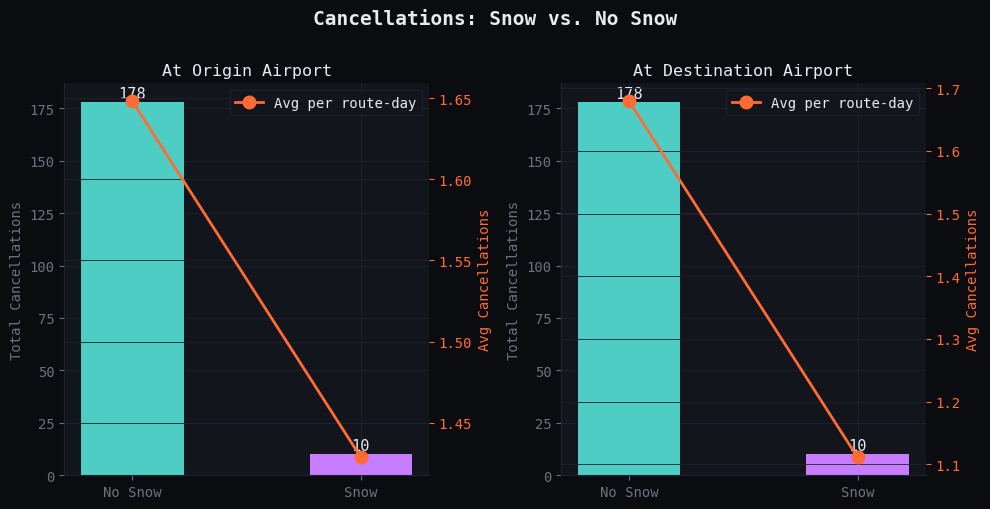

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Cancellations: Snow vs. No Snow', fontsize=14, fontweight='bold', color=TEXT, y=1.01)

for ax, col, title in zip(
    axes,
    ['origin_snow', 'dest_snow'],
    ['At Origin Airport', 'At Destination Airport']
):
    daily['has_snow'] = daily[col] > 0
    snow_stats = daily.groupby('has_snow')['cancellations'].agg(['sum', 'mean']).reset_index()
    snow_stats['label'] = snow_stats['has_snow'].map({False: 'No Snow', True: 'Snow'})

    bars = ax.bar(snow_stats['label'], snow_stats['sum'],
                  color=[C2, C4], width=0.45, zorder=3)
    ax2 = ax.twinx()
    ax2.plot(snow_stats['label'], snow_stats['mean'],
             color=C1, marker='o', markersize=9, linewidth=2, zorder=4, label='Avg per route-day')
    ax2.set_ylabel('Avg Cancellations', color=C1)
    ax2.tick_params(axis='y', colors=C1)
    ax2.set_facecolor(SURFACE)

    for bar, val in zip(bars, snow_stats['sum']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(int(val)), ha='center', va='bottom', fontsize=11, color=TEXT)

    ax.set_title(title, color=TEXT)
    ax.set_ylabel('Total Cancellations', color=MUTED)
    ax2.legend(facecolor=SURFACE, edgecolor=GRID, labelcolor=TEXT, loc='upper right')

plt.tight_layout()
plt.show()